In [1]:
from google.colab import files
print("Enter your dataset")
uploaded = files.upload()

Enter your dataset


Saving fake_or_real_news.csv to fake_or_real_news.csv


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , precision_score,recall_score,f1_score,confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer


In [5]:
df = pd.read_csv('fake_or_real_news.csv')
print(df.head())

   Unnamed: 0                                              title  \
0        8476                       You Can Smell Hillary’s Fear   
1       10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2        3608        Kerry to go to Paris in gesture of sympathy   
3       10142  Bernie supporters on Twitter erupt in anger ag...   
4         875   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  


In [7]:
df = df.drop(["Unnamed: 0"] , axis =1)
print(df.head())

                                               title  \
0                       You Can Smell Hillary’s Fear   
1  Watch The Exact Moment Paul Ryan Committed Pol...   
2        Kerry to go to Paris in gesture of sympathy   
3  Bernie supporters on Twitter erupt in anger ag...   
4   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  


In [24]:
df['label'] = df['label'].map({'REAL': 1, 'FAKE': 0})
display(df.head())

,title,text,label,full_text
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",0,You Can Smell Hillary’s Fear Daniel Greenfield...
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,0,Watch The Exact Moment Paul Ryan Committed Pol...
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,1,Kerry to go to Paris in gesture of sympathy U....
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",0,Bernie supporters on Twitter erupt in anger ag...
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,1,The Battle of New York: Why This Primary Matte...


In [10]:
cv = CountVectorizer(tokenizer = lambda x: x.split())
df['text'] = df['text'].fillna('')
df['title'] = df['title'].fillna('')

In [27]:
df['full_text'] = df['title'] + ' ' + df['text']
words = cv.fit_transform(df['full_text'])
model = LogisticRegression(max_iter=1000)
X_train , X_test , y_train , y_test = train_test_split(words , df['label'] , test_size = 0.2)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


LogisticRegression(max_iter=1000)

In [28]:
y_predict = model.predict(X_test)

In [29]:
Accuracy = accuracy_score(y_test , y_predict)*100
print('Accuracy of model:' , Accuracy)
Recall = recall_score(y_test , y_predict)*100
print('Recall of model:' , Recall)
Precision = precision_score(y_test , y_predict)*100
print('Precision of model:' , Precision)
F1_score = f1_score(y_test , y_predict)*100
print('F1_score of model:' , F1_score)

Accuracy of model: 94.00157853196527
Recall of model: 94.10852713178295
Precision of model: 94.10852713178295
F1_score of model: 94.10852713178295


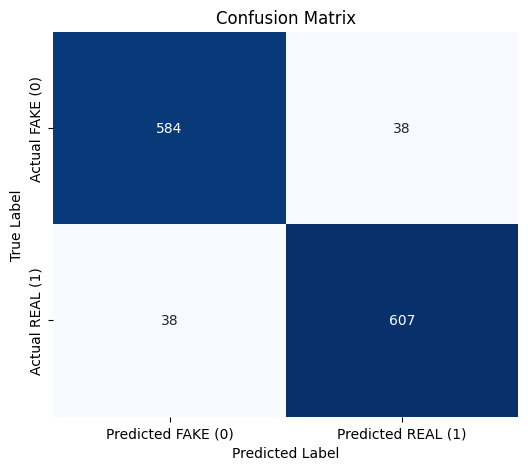

In [32]:


cm = confusion_matrix(y_test, y_predict)
mt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted FAKE (0)', 'Predicted REAL (1)'],
            yticklabels=['Actual FAKE (0)', 'Actual REAL (1)'])
mt.xlabel('Predicted Label')
mt.ylabel('True Label')
mt.title('Confusion Matrix')
mt.show()